# Per-task accuracy — trained from scratch

Joint all-task PLRNN (M=64, P=2, n=50) trained from scratch at batch size 16.
Accuracies are the per-task **test** accuracy at each run's best epoch
(`best_test_accuracies` in `results.npz`), aggregated across seeds 0–3.

Accuracy thresholds used during training (a trial counts as correct if its
error is below the threshold): **NoiseCleaner = 10°**, **ArithMultiply /
ArithAdd = 0.05** (scalar error), all other angular tasks = the default
**20°** (`THRESHOLD` in `rnn_model.py`). Go/Nogo-style binary channels use a
0.5 decision threshold.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Walk up from the notebook's location to find the run directory, so this
# works whether launched from its own folder or the repo root. We match the
# full relative path (not just any `results/`) to skip nested results dirs.
REL = "results/individual_training/all/20260106_individual_16_batch_size"
CONFIG = "M64_P2_N50"
SEEDS = [0, 1, 2, 3]

_here = Path.cwd()
RESULTS_DIR = next(
    (p / REL for p in (_here, *_here.parents) if (p / REL).is_dir()), None
)
assert RESULTS_DIR is not None, f"Could not locate {REL} starting from {_here}"
print("Results dir:", RESULTS_DIR)

Results dir: C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\results\individual_training\all\20260106_individual_16_batch_size


In [2]:
# Load each seed's per-task accuracy at its best epoch.
per_seed = {}
task_names = None
best_epochs = {}
overall_mean = {}

for seed in SEEDS:
    npz_path = RESULTS_DIR / f"seed_{seed}" / CONFIG / "results.npz"
    d = np.load(npz_path, allow_pickle=True)
    if task_names is None:
        task_names = [str(n) for n in d["task_names"]]
    acc_by_id = d["best_test_accuracies"].item()  # {task_id: accuracy}
    per_seed[seed] = [acc_by_id[i] for i in range(len(task_names))]
    best_epochs[seed] = int(d["best_epoch"])
    overall_mean[seed] = float(d["best_test_accuracy"])

print("Tasks:", len(task_names))
print("Best epoch per seed:", best_epochs)
print("Mean accuracy per seed:", {s: round(v, 4) for s, v in overall_mean.items()})

Tasks: 19
Best epoch per seed: {0: 455, 1: 379, 2: 456, 3: 386}
Mean accuracy per seed: {0: 0.6472, 1: 0.6151, 2: 0.567, 3: 0.5657}


In [3]:
# Build a tidy table: one row per task, one column per seed, plus mean/std.
df = pd.DataFrame(per_seed, index=task_names)
df.columns = [f"seed_{s}" for s in SEEDS]
df["mean"] = df.mean(axis=1)
df["std"] = df[[f"seed_{s}" for s in SEEDS]].std(axis=1, ddof=0)
df = df.sort_values("mean", ascending=False)

df.style.format("{:.3f}").background_gradient(
    subset=["mean"], cmap="RdYlGn", vmin=0, vmax=1
)

,seed_0,seed_1,seed_2,seed_3,mean,std
CatPro,0.983,0.600,0.902,0.929,0.854,0.149
DelayPro,1.000,0.912,0.525,0.945,0.846,0.188
MultiSens,0.928,0.760,0.835,0.821,0.836,0.060
CatAnti,0.890,0.780,0.833,0.797,0.825,0.042
IntDisc,0.782,0.893,0.819,0.779,0.818,0.046
PerceptualDM,0.987,0.980,0.833,0.188,0.747,0.329
CtxIntMod1,0.807,0.737,0.445,0.660,0.662,0.136
Match2Sample,0.626,0.565,0.617,0.585,0.598,0.025
GoNogo,0.623,0.493,0.611,0.657,0.596,0.062
NoiseCleaner,0.564,0.784,0.333,0.696,0.594,0.170


C:\Users\garcias\AppData\Local\Temp\claude\ipykernel_38724\2110126312.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=60, ha="right")


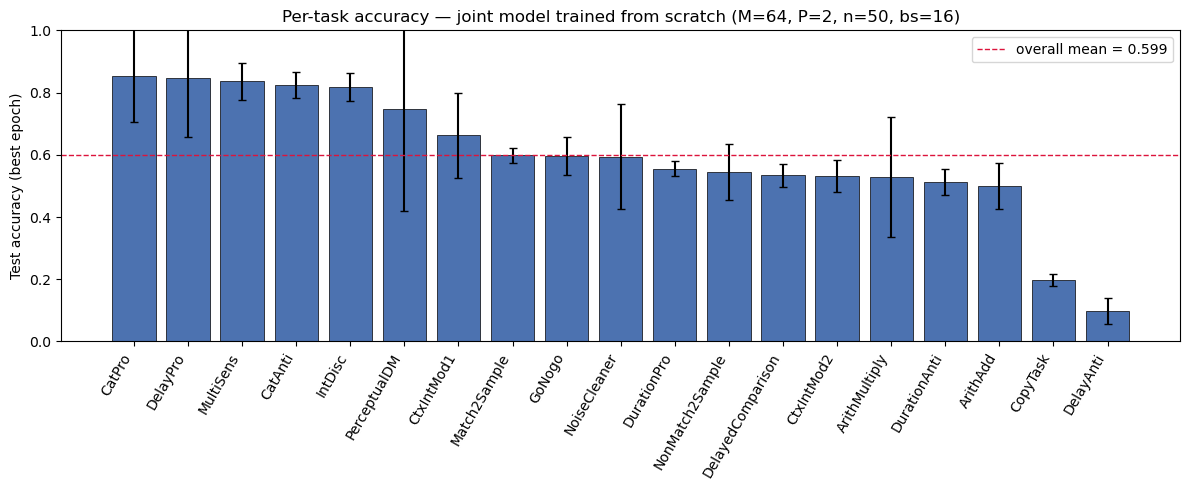

In [4]:
# Bar plot: mean per-task accuracy across seeds, with std error bars.
order = df.index.tolist()
means = df["mean"].values
stds = df["std"].values

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(order, means, yerr=stds, capsize=3, color="#4C72B0", edgecolor="black", linewidth=0.5)
ax.axhline(np.mean(list(overall_mean.values())), color="crimson", ls="--", lw=1,
           label=f"overall mean = {np.mean(list(overall_mean.values())):.3f}")
ax.set_ylabel("Test accuracy (best epoch)")
ax.set_ylim(0, 1)
ax.set_title("Per-task accuracy — joint model trained from scratch (M=64, P=2, n=50, bs=16)")
ax.set_xticklabels(order, rotation=60, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Plain-text summary, highest → lowest.
print(f"{'task':<18} {'mean':>6} {'std':>6}")
print("-" * 32)
for name, row in df.iterrows():
    print(f"{name:<18} {row['mean']:>6.3f} {row['std']:>6.3f}")
print("-" * 32)
print(f"{'OVERALL':<18} {df['mean'].mean():>6.3f}")

task                 mean    std
--------------------------------
CatPro              0.854  0.149
DelayPro            0.846  0.188
MultiSens           0.836  0.060
CatAnti             0.825  0.042
IntDisc             0.818  0.046
PerceptualDM        0.747  0.329
CtxIntMod1          0.662  0.136
Match2Sample        0.598  0.025
GoNogo              0.596  0.062
NoiseCleaner        0.594  0.170
DurationPro         0.555  0.024
NonMatch2Sample     0.544  0.091
DelayedComparison   0.533  0.038
CtxIntMod2          0.532  0.051
ArithMultiply       0.528  0.193
DurationAnti        0.512  0.042
ArithAdd            0.498  0.074
CopyTask            0.197  0.019
DelayAnti           0.098  0.041
--------------------------------
OVERALL             0.599


## Epochs to reach a target accuracy

Using the per-epoch test-accuracy curves, find the **first epoch** at which
each task crosses `TARGET_ACC`. A task that never reaches the target shows
`NaN` (and `n_seeds_reached` < number of seeds). Epochs are 0-indexed.

In [6]:
# Per-epoch test-accuracy curves -> first epoch each task reaches TARGET_ACC.
TARGET_ACC = 0.8  # <-- change to the % you care about (e.g. 0.5, 0.9)

# Load the full per-epoch curves: seed -> (n_tasks, n_epochs).
acc_curves = {}
for seed in SEEDS:
    d = np.load(RESULTS_DIR / f"seed_{seed}" / CONFIG / "results.npz", allow_pickle=True)
    tta = d["test_task_accuracies"].item()  # {task_id: array(n_epochs,)}
    acc_curves[seed] = np.array(
        [np.asarray(tta[i], dtype=float) for i in range(len(task_names))]
    )


def first_crossing(curve, target):
    """First epoch index where curve >= target, or None if never reached."""
    hit = np.where(curve >= target)[0]
    return int(hit[0]) if hit.size else None


rows = []
for ti, name in enumerate(task_names):
    per_seed_epoch = {
        seed: first_crossing(acc_curves[seed][ti], TARGET_ACC) for seed in SEEDS
    }
    reached = [e for e in per_seed_epoch.values() if e is not None]
    rows.append(
        {
            "task": name,
            "n_seeds_reached": len(reached),
            "mean_epoch": np.mean(reached) if reached else np.nan,
            "std_epoch": np.std(reached) if reached else np.nan,
            **{f"seed_{s}": per_seed_epoch[s] for s in SEEDS},
        }
    )

ep_df = pd.DataFrame(rows).set_index("task").sort_values(
    ["n_seeds_reached", "mean_epoch"], ascending=[False, True]
)
print(f"Epochs to first reach test accuracy >= {TARGET_ACC:.0%} (0-indexed)")
ep_df

Epochs to first reach test accuracy >= 80% (0-indexed)


,n_seeds_reached,mean_epoch,std_epoch,seed_0,seed_1,seed_2,seed_3
task,,,,,,,
CatPro,4,102.000000,60.228731,38.0,180.0,49.0,141.0
IntDisc,4,168.500000,173.103293,43.0,133.0,37.0,461.0
DelayPro,4,238.250000,77.296103,183.0,189.0,371.0,210.0
MultiSens,4,377.750000,51.620611,313.0,357.0,455.0,386.0
CatAnti,3,115.333333,122.096501,288.0,30.0,28.0,NaN
CtxIntMod1,3,223.333333,3.299832,221.0,228.0,NaN,221.0
PerceptualDM,3,236.666667,136.160037,94.0,196.0,420.0,NaN
NoiseCleaner,3,357.333333,107.021286,338.0,237.0,NaN,497.0
DelayedComparison,3,368.000000,158.444522,485.0,NaN,475.0,144.0


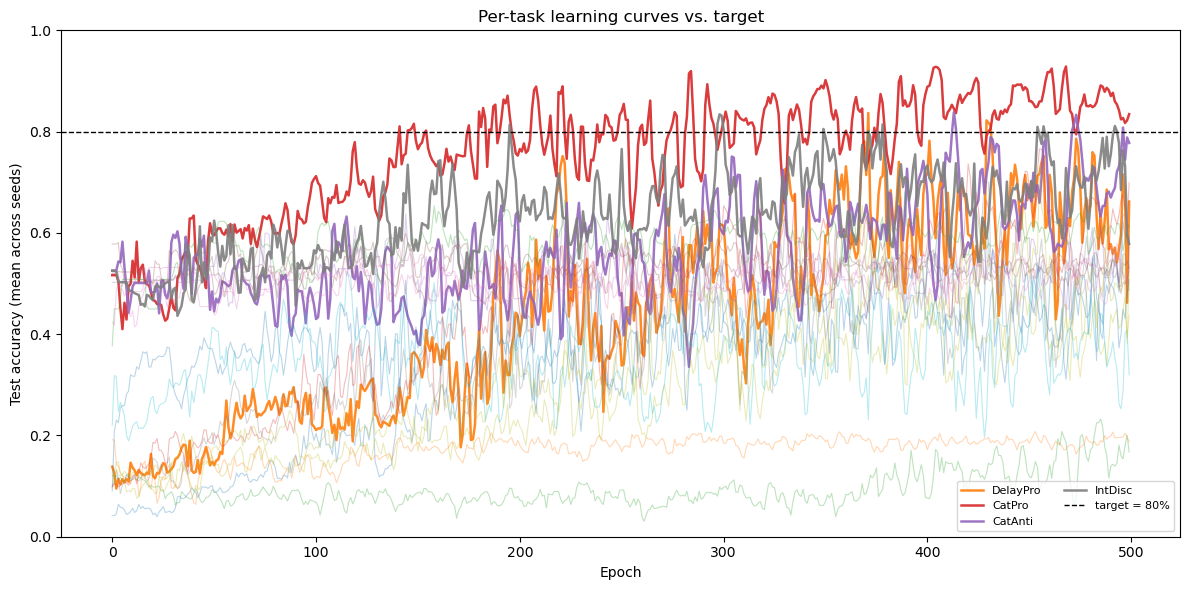

In [7]:
# Mean learning curves (averaged across seeds) with the target line, so you
# can see when each task crosses TARGET_ACC. Tasks that reach it are bold.
mean_curve = np.mean([acc_curves[s] for s in SEEDS], axis=0)  # (n_tasks, n_epochs)

fig, ax = plt.subplots(figsize=(12, 6))
for ti, name in enumerate(task_names):
    reached = mean_curve[ti].max() >= TARGET_ACC
    ax.plot(mean_curve[ti], lw=1.8 if reached else 0.8,
            alpha=0.9 if reached else 0.3, label=name if reached else None)
ax.axhline(TARGET_ACC, color="black", ls="--", lw=1, label=f"target = {TARGET_ACC:.0%}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test accuracy (mean across seeds)")
ax.set_ylim(0, 1)
ax.set_title("Per-task learning curves vs. target")
ax.legend(ncol=2, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()